In [277]:
import random
import numpy as np
import scanpy as sc
from os import path
import matplotlib.pyplot as plt
import numpy as np

In [278]:
slice_path = '../selected_slices/T1099_MT67_7M_Visual_Sub-CTX_V12_b100_filtered.h5ad'

In [279]:
ad = sc.read_h5ad(slice_path)

In [280]:
sc.pp.calculate_qc_metrics(ad, inplace=True)

In [281]:
ad

AnnData object with n_obs × n_vars = 15073 × 29518
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'

In [282]:
ad.obs

,pct_counts_mt,orig.ident,x,y,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
40802189326800,1.138330,sample,9500,14800,4910,8.499233,10981,9.304013,16.200710,20.872416,27.593115,40.834168
65712999635800,1.780675,sample,15300,7000,4632,8.440960,10277,9.237761,16.814245,21.961662,28.870293,42.415102
47244640269300,1.486609,sample,11000,13300,4257,8.356555,8812,9.083983,18.009532,22.514753,29.017249,42.192465
32212254741500,0.451807,sample,7500,21500,1701,7.439559,2656,7.884953,22.703313,28.915663,37.500000,54.781627
33930241656000,1.816430,sample,7900,17600,3708,8.218518,7267,8.891236,20.214669,25.017201,31.594881,45.190588
...,...,...,...,...,...,...,...,...,...,...,...,...
34359738386800,1.112619,sample,8000,18800,4740,8.464003,11055,9.310729,17.213930,22.930801,30.194482,43.165988
56693568322500,2.062155,sample,13200,15300,3627,8.196437,6886,8.837391,19.488818,24.106884,30.641882,44.191112
54116587941400,1.431820,sample,12600,11800,5067,8.530702,11873,9.382106,15.741599,20.719279,27.541481,41.034279
22763326682500,1.104000,sample,5300,13700,3364,8.121183,6250,8.740497,20.672000,25.280000,32.112000,45.760000


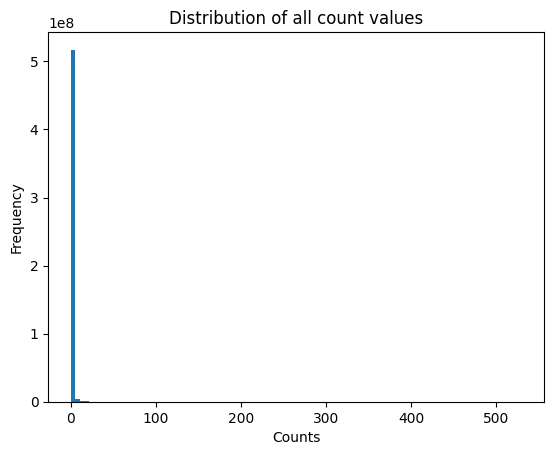

In [283]:
if sp.issparse(X):
    vals = X.toarray().ravel()
else:
    vals = np.asarray(X).ravel()

plt.hist(vals, bins=100)
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.title("Distribution of all count values")
plt.show()

Zero fraction: 0.8599214900160637


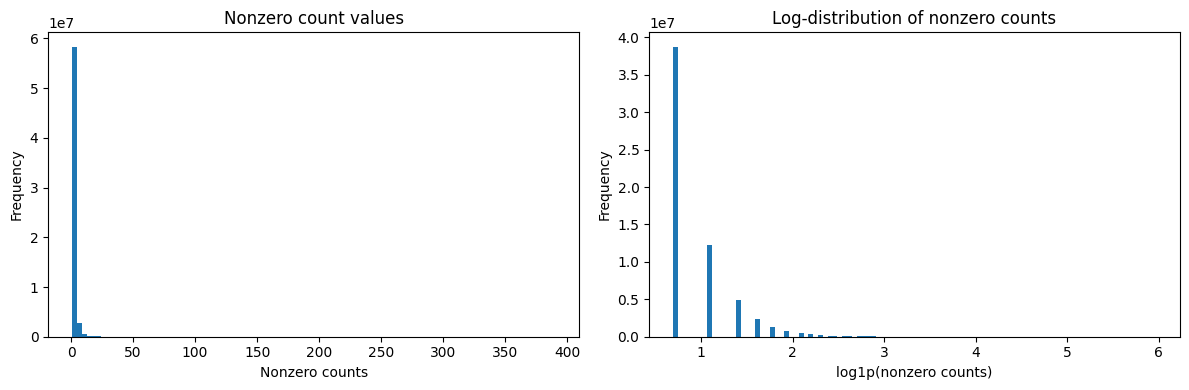

In [284]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

X = ad.X

if sp.issparse(X):
    vals_nz = X.data
    zero_fraction = 1 - X.nnz / (X.shape[0] * X.shape[1])
else:
    vals = np.asarray(X).ravel()
    vals_nz = vals[vals > 0]
    zero_fraction = np.mean(vals == 0)

print("Zero fraction:", zero_fraction)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(vals_nz, bins=100)
plt.xlabel("Nonzero counts")
plt.ylabel("Frequency")
plt.title("Nonzero count values")

plt.subplot(1, 2, 2)
plt.hist(np.log1p(vals_nz), bins=100)
plt.xlabel("log1p(nonzero counts)")
plt.ylabel("Frequency")
plt.title("Log-distribution of nonzero counts")

plt.tight_layout()
plt.show()

In [285]:
X.shape

(15073, 29518)

In [286]:
X.mean(axis=0).shape

(1, 29518)

In [287]:
 X.sum(axis=0).shape

(1, 29518)

In [288]:
 X.sum(axis=0)

matrix([[   26,    27,  1287, ...,  1791,  7104, 10080]], dtype=uint64)

In [289]:
gene_sums = np.asarray(X.sum(axis=0)).ravel()

<AxesSubplot:>

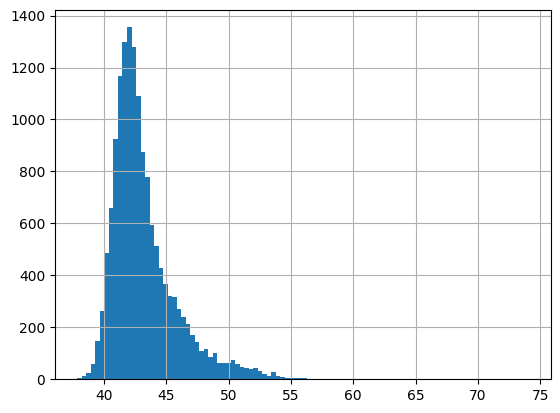

In [290]:
ad.obs.pct_counts_in_top_500_genes.hist(bins=100)

<AxesSubplot:>

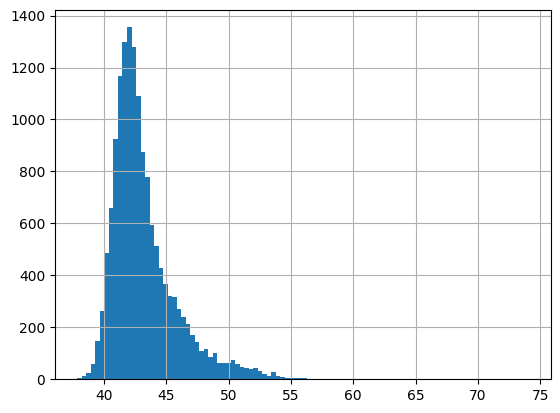

In [291]:
ad.obs.pct_counts_in_top_500_genes.hist(bins=100)

<AxesSubplot:>

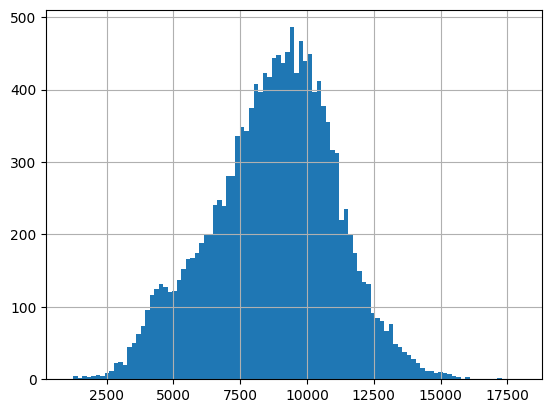

In [292]:
ad.obs.total_counts.hist(bins=100)

<AxesSubplot:>

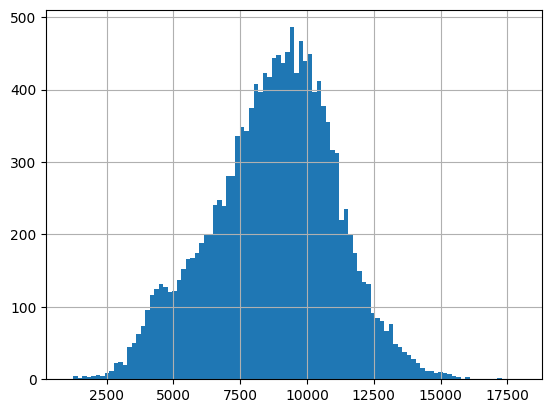

In [293]:
tc = ad.obs.total_counts
tc.hist(bins=100)

<AxesSubplot:>

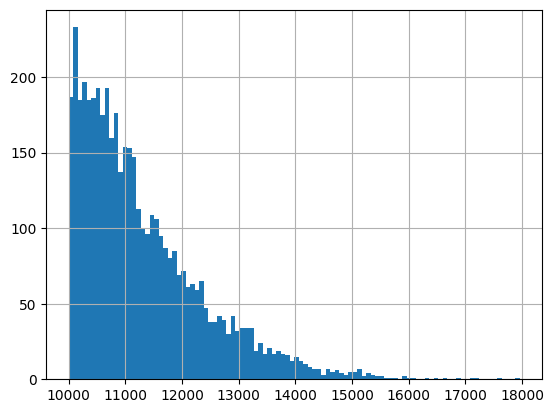

In [294]:
tc[tc>10000].hist(bins=100)

In [295]:
(tc<12000).sum()

14058

In [296]:
sc.pp.filter_cells(ad, min_counts=100)
sc.pp.filter_genes(ad, min_cells=1)

In [297]:
ad.layers = {"counts":ad.X.copy()} 

In [298]:
sc.pp.normalize_total(ad, inplace=True, layers=None, key_added="sizefactor")
sc.pp.log1p(ad)

<AxesSubplot:>

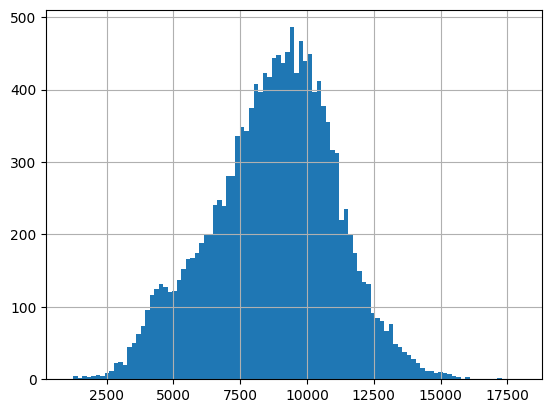

In [299]:
tc = ad.obs.total_counts
tc.hist(bins=100)

In [300]:
ad.var

,real_gene_name,n_cells,n_counts,mean_umi,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A1BG,A1BG,26,26,1.000000,26,0.001725,0.001723,99.827506,26,3.295837
A1CF,A1CF,26,27,1.038462,26,0.001791,0.001790,99.827506,27,3.332205
A2M,A2M,1181,1291,1.089451,1181,0.085384,0.081934,92.164798,1287,7.160846
A2ML1,A2ML1,450,477,1.060000,450,0.031646,0.031156,97.014529,477,6.169611
A3GALT2,A3GALT2,139,143,1.028777,139,0.009487,0.009442,99.077821,143,4.969813
...,...,...,...,...,...,...,...,...,...,...
ZYG11A,ZYG11A,317,330,1.041009,317,0.021893,0.021657,97.896902,330,5.802118
ZYG11B,ZYG11B,10442,20514,1.962499,10442,1.359782,0.858569,30.723811,20496,9.928034
ZYX,ZYX,1663,1793,1.076877,1663,0.118822,0.112276,88.967027,1791,7.491088
ZZEF1,ZZEF1,5284,7117,1.344098,5284,0.471306,0.386151,64.943939,7104,8.868554


In [301]:
import numpy as np
import scipy.sparse as sp

def compute_poisson_deviance(adata, layer=None, size_factors=None, chunk_size=1024):
    """
    Compute gene-wise Poisson deviance and store in adata.var['deviance_poisson'].

    Parameters
    ----------
    adata : AnnData
        AnnData object with counts in adata.X or in adata.layers[layer].
    layer : str or None
        Which layer to use. If None, uses adata.X.
        For NSF-style preprocessing, this should usually be raw counts.
    size_factors : array-like or None
        Optional per-observation size factors / library sizes.
        If None, uses row sums of the count matrix.
    chunk_size : int
        Number of genes to process at once for dense conversion when matrix is sparse.

    Returns
    -------
    dev : np.ndarray
        Array of shape (n_genes,) with Poisson deviances.
    """
    X = adata.layers[layer] if layer is not None else adata.X

    # Use raw counts as float
    if sp.issparse(X):
        X = X.tocsr()
    else:
        X = np.asarray(X, dtype=np.float64)

    n_obs, n_vars = adata.shape

    # Library sizes / exposure
    if size_factors is None:
        if sp.issparse(X):
            sf = np.asarray(X.sum(axis=1)).ravel().astype(np.float64)
        else:
            sf = X.sum(axis=1).astype(np.float64)
    else:
        sf = np.asarray(size_factors, dtype=np.float64).ravel()

    # Avoid division-by-zero observations
    valid_obs = sf > 0
    if not np.all(valid_obs):
        print(f"Filtering out {(~valid_obs).sum()} observations with zero total counts.")
        sf = sf[valid_obs]
        if sp.issparse(X):
            X = X[valid_obs]
        else:
            X = X[valid_obs, :]

    sf_sum = sf.sum()
    dev = np.zeros(n_vars, dtype=np.float64)

    # Process gene blocks
    for start in range(0, n_vars, chunk_size):
        end = min(start + chunk_size, n_vars)

        if sp.issparse(X):
            Y = X[:, start:end].toarray().astype(np.float64)   # shape: n_obs x block
        else:
            Y = X[:, start:end].astype(np.float64)

        # Gene totals
        gene_totals = Y.sum(axis=0)  # shape: block

        # Null model: mu_ij = sf_i * (sum_j y_ij / sum_i sf_i)
        # equivalently mu[:, g] = sf * gene_total[g] / sf_sum
        MU = np.outer(sf, gene_totals / sf_sum)

        # Compute term y * log(y/mu), with convention 0*log(0/mu)=0
        term = np.zeros_like(Y, dtype=np.float64)
        positive = Y > 0
        term[positive] = Y[positive] * np.log(Y[positive] / MU[positive])

        dev_block = 2.0 * np.sum(term - (Y - MU), axis=0)
        dev[start:end] = dev_block

    adata.var["deviance_poisson"] = dev
    return dev

In [302]:
ad.var

,real_gene_name,n_cells,n_counts,mean_umi,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A1BG,A1BG,26,26,1.000000,26,0.001725,0.001723,99.827506,26,3.295837
A1CF,A1CF,26,27,1.038462,26,0.001791,0.001790,99.827506,27,3.332205
A2M,A2M,1181,1291,1.089451,1181,0.085384,0.081934,92.164798,1287,7.160846
A2ML1,A2ML1,450,477,1.060000,450,0.031646,0.031156,97.014529,477,6.169611
A3GALT2,A3GALT2,139,143,1.028777,139,0.009487,0.009442,99.077821,143,4.969813
...,...,...,...,...,...,...,...,...,...,...
ZYG11A,ZYG11A,317,330,1.041009,317,0.021893,0.021657,97.896902,330,5.802118
ZYG11B,ZYG11B,10442,20514,1.962499,10442,1.359782,0.858569,30.723811,20496,9.928034
ZYX,ZYX,1663,1793,1.076877,1663,0.118822,0.112276,88.967027,1791,7.491088
ZZEF1,ZZEF1,5284,7117,1.344098,5284,0.471306,0.386151,64.943939,7104,8.868554


In [303]:
dev = compute_poisson_deviance(ad, layer=None)

<AxesSubplot:>

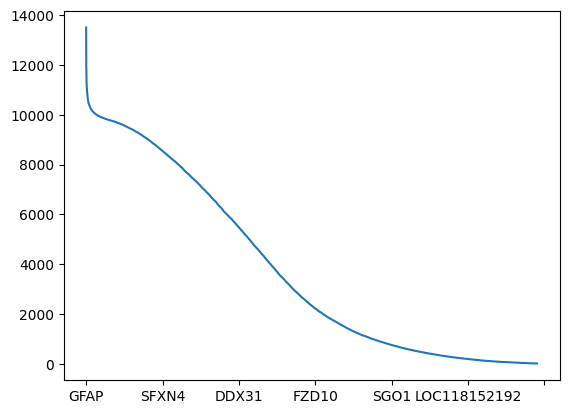

In [304]:
o = np.argsort(-ad.var['deviance_poisson'])
idx = list(range(ad.shape[0]))
random.shuffle(idx)
ad = ad[idx,o]
ad.var["deviance_poisson"].plot()

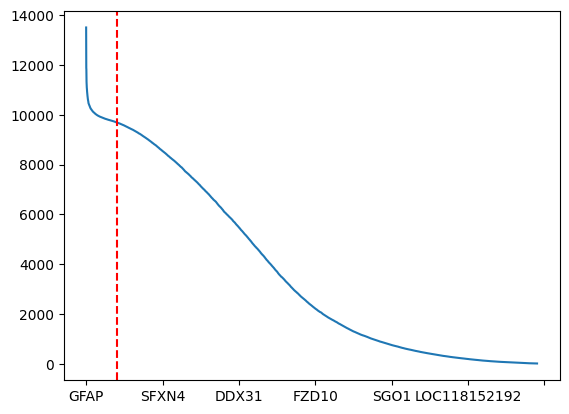

In [305]:
ad.var["deviance_poisson"].plot()
plt.axvline(2000, color="red", linestyle="--")

In [306]:
dev = ad.var["deviance_poisson"].values

print("min:", dev.min())
print("median:", np.median(dev))
print("q25:", np.quantile(dev, 0.25))
print("q75:", np.quantile(dev, 0.75))
print("max:", dev.max())

min: 7.818921025285126
median: 2335.5241337716984
q25: 442.6772534129407
q75: 7206.6043464207505
max: 13503.66601766308


In [307]:
ad2 = ad[:,:2000]
ad2.write_h5ad("data/T1099_MT67_7M_Visual_Sub-CTX_V12_b100_filtered_J2000.h5ad",compression="gzip")

In [308]:
ad2

View of AnnData object with n_obs × n_vars = 15073 × 2000
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'sizefactor'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'deviance_poisson'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'log1p'
    obsm: 'spatial'
    layers: 'counts'

In [309]:
ad2.var.real_gene_name.to_csv("res/T1099-7M/T1099-7M_selected_genes.csv", index= False)

In [310]:
ad2.var.real_gene_name

GFAP          GFAP
ST18          ST18
CRYAB        CRYAB
CNP            CNP
SELENOP    SELENOP
            ...   
TARDBP      TARDBP
ATP5MD      ATP5MD
RIMS4        RIMS4
DBNDD2      DBNDD2
BSDC1        BSDC1
Name: real_gene_name, Length: 2000, dtype: object

In [311]:
import pandas as pd

In [312]:
T1089_selected_genes = pd.read_csv("res/T1089-P0/T1089_P0_selected_genes.csv")

In [313]:
intersection = set(T1089_selected_genes["real_gene_name"].values) & set(ad2.var.real_gene_name.values)

In [314]:
len(intersection)

480